# Лабораторная работа №3 (доработанная)



## Теоретическая часть

### Решающие деревья

Решающее дерево — это непараметрический метод обучения с учителем, который строит модель в виде набора простых правил вида "если‐то". Дерево разбивает пространство признаков на области, а в листовых узлах хранит предсказания. Среди преимуществ деревьев — простота интерпретации и способность работать с числовыми и категориальными данными; для их использования не требуется масштабирование признаков, а прогнозирование имеет логарифмическую сложность по числу обучающих примеров. Недостатком одиночных деревьев является высокая дисперсия и склонность к переобучению.

### Метод опорных векторов (SVM)

Метод опорных векторов — семейство алгоритмов обучения с учителем, используемых для классификации, регрессии и задач обнаружения выбросов. Он ищет разделяющую гиперплоскость с максимальным зазором между классами в пространстве признаков. К достоинствам SVM относят эффективность в задачах с большим числом признаков, способность работать, когда число признаков превышает число примеров, и использование лишь части обучающих точек (опорных векторов), что делает модель компактной. Метод поддерживает различные ядра, что позволяет строить нелинейные разделяющие поверхности. Среди недостатков — необходимость подбора ядра и параметров регуляризации и дорогая оценка вероятностей.

### Случайный лес

Случайный лес — ансамблевый алгоритм, который объединяет множество решающих деревьев, построенных на случайных подвыборках данных и случайных поднаборах признаков. Деревья обучаются на bootstrap-выборках; для каждого узла рассматривается случайное подмножество признаков. Такая случайность снижает дисперсию моделей: отдельные деревья переобучаются, но усреднение их предсказаний приводит к более устойчивой модели. В реализациях scikit‑learn усредняются вероятностные предсказания деревьев, что часто увеличивает точность.

### Преобразование признаков и сокращение размерности

**Histogram of Oriented Gradients (HOG).** Визуальный дескриптор HOG анализирует распределение ориентаций градиентов в локальных областях изображения. Для каждого пикселя вычисляются величина и направление градиента, затем изображение разбивается на ячейки, и в каждой строится гистограмма направлений. Дескриптор акцентирует структуру или форму объекта, поскольку учитывает не только наличие границы, но и её направление. Итоговый признак для изображения представляет собой вектор, содержащий гистограммы для всех ячеек.

**Local Binary Pattern (LBP).** LBP — простой дескриптор текстуры. Для каждой точки берутся пиксели в окружности; значения сравниваются с центральным пикселем, образуя двоичный код, который интерпретируется как число. Сопоставляя гистограммы LBP по всему изображению, можно описывать типы текстур. На схеме LBP показано, что сравниваются восемь соседей; последовательности из всех чёрных или белых точек соответствуют ровным областям, а чередование указывает на углы или более сложные структуры.

**Principal Component Analysis (PCA).** PCA — метод линейного снижения размерности, который разлагает исходные данные на набор ортогональных компонентов, объясняющих наибольшую дисперсию. Алгоритм центрирует данные и находит главные компоненты с помощью сингулярного разложения; полученный трансформер позволяет проектировать новые данные в пространство меньшей размерности. Параметр `whiten=True` масштабирует компоненты до единичной дисперсии, что бывает полезно для алгоритмов, чувствительных к масштабу признаков.



### Разминочные задания

#### Задание A. Классификация простых прямоугольников

1. Сгенерируйте синтетический набор изображений. Каждое изображение – это трёхканальный массив фиксированного размера (например, 20×20 пикселей). Внутри изображения находится прямоугольник одного из цветов: красный (значение 1 только в красном канале), зелёный или синий. Ширина и высота прямоугольника выбираются случайным образом в пределах заданного диапазона.
2. Сформируйте выборку изображений и соответствующие метки классов: 0 — красный прямоугольник, 1 — зелёный, 2 — синий. Преобразуйте изображения в табличный вид, развернув их в одномерные векторы признаков.
3. Разделите данные на обучающую и тестовую выборки (например, 70 % / 30 %). Обучите три классификатора: решающее дерево (`DecisionTreeClassifier`), линейный SVM (`SVC(kernel='linear')`) и случайный лес (`RandomForestClassifier`).
4. Оцените точность каждого алгоритма на тестовой выборке и сравните результаты.

#### Задание B. Классификация рукописных цифр с классическими признаками

1. Загрузите набор данных `load_digits` из `sklearn.datasets` (это упрощённый аналог MNIST: изображения 8×8 пикселей). Разделите выборку на обучающую и тестовую.
2. Для каждого изображения извлеките признаки с помощью дескриптора HOG. Для этого можно использовать функцию `skimage.feature.hog` и указать параметры `orientations=9`, `pixels_per_cell=(4,4)`, `cells_per_block=(1,1)`. Получите матрицу признаков.
3. При необходимости уменьшите размерность признаков с помощью `PCA` до разумного числа компонент (например, 20).
4. Обучите и сравните три классификатора: решающее дерево, SVM с радиальным ядром (`SVC(kernel='rbf')`) и случайный лес. Выведите точность каждого алгоритма на тестовой выборке.
5. Проанализируйте, какие методы показали лучшие результаты на этом наборе данных и почему.


In [ ]:

# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
from skimage.feature import hog
from sklearn.decomposition import PCA

# ===== Задание A =====
# TODO: сгенерировать изображения с прямоугольниками разных цветов
# Создайте пустой список для изображений и меток
images = []
labels = []
# Например, можно задать размер холста 20x20 и случайным образом выбирать ширину и высоту прямоугольника
# Заполните списки images и labels соответствующими значениями

# TODO: преобразовать изображения в векторы признаков
# X = ...
# y = ...

# TODO: разделить данные на обучающую и тестовую выборки
# X_train, X_test, y_train, y_test = train_test_split(...)

# TODO: обучить и оценить классификаторы DecisionTree, SVM и RandomForest
# for name, model in models.items():
#     model.fit(...)
#     preds = model.predict(...)
#     print(name, accuracy_score(...))




In [ ]:

# ===== Задание B =====
# Загрузка датасета
# digits = load_digits()
# images = digits.images
# labels = digits.target

# TODO: извлечь HOG-признаки для каждой картинки
# hog_features = []
# for img in images:
#     fd = hog(img, orientations=9, pixels_per_cell=(4,4), cells_per_block=(1,1), visualize=False)
#     hog_features.append(fd)
# features = np.array(hog_features)

# TODO: при необходимости применить PCA для уменьшения размерности
# pca = PCA(n_components=20)
# features_pca = pca.fit_transform(features)

# TODO: разделить данные на обучающую и тестовую выборки
# X_train, X_test, y_train, y_test = train_test_split(...)

# TODO: обучить и оценить классификаторы DecisionTree, SVM и RandomForest
# ...

##Лабораторная работа №3 Классификаторы изображений на базе традиционного МО и ИНС

###Задание 1
Загрузите датасет CIFAR-10, подготовьте обучающую и тестовую выборку, применив масштабирование изображений

In [1]:
# Лабораторная работа 3: Линейные классификаторы изображений
# Импорт библиотек
!pip install -q matplotlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import cifar10

##Задание 2
Создайте функцию визуализации изображений из датасета. Выведите примеры некоторых изображений и классов к ним.

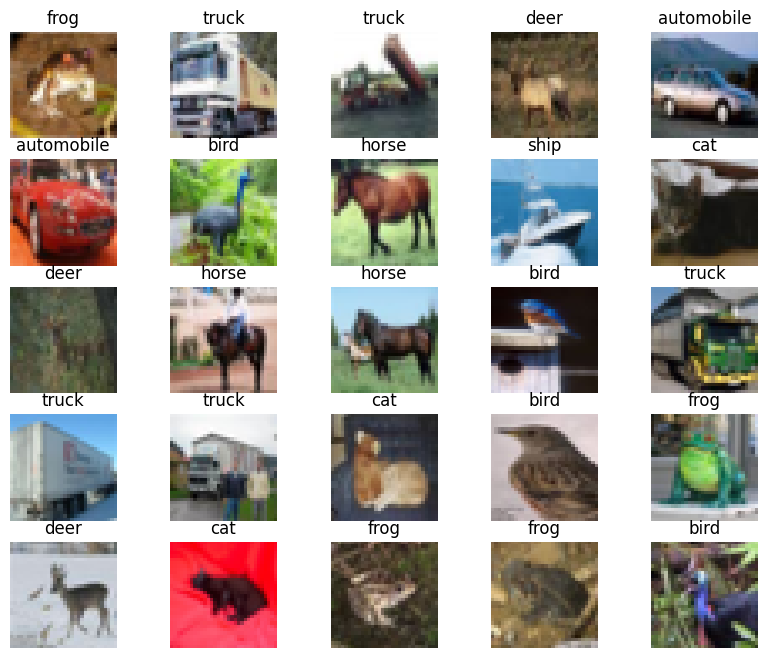

##Задание 3
Создайте класс линейного классификатора с возможностью задавать число входных нейронов и число выходных нейронов. Подготовьте изображения в одномерном представлении для подачи на вход такого классификатора и используйте правильные параметры для нейросети. Посчитайте прогон такой модели при случайной инициализации весовых коэффициентов.

[[-0.00883955  0.03384205 -0.00232839 -0.03185328 -0.00153263  0.04226584
  -0.01312082 -0.03564472  0.03756668 -0.00580203]
 [ 0.02794398  0.04156493  0.00696662 -0.02009795 -0.00061415  0.03099362
   0.00166198 -0.01971176  0.07500619  0.02431455]
 [ 0.03387568  0.03893309  0.01105405 -0.01564438 -0.0029603   0.09272575
  -0.00216747 -0.05647615  0.05742659  0.0140049 ]
 [ 0.01109901  0.02691806 -0.00913786 -0.02268722  0.00161163  0.03220905
  -0.0069535  -0.01863428  0.02798316 -0.00569967]
 [ 0.03772014  0.01284288  0.00404206  0.0022221  -0.0078117   0.06994119
   0.00628976 -0.03245102  0.0451152   0.00173708]
 [-0.01147973  0.04805622  0.00923233 -0.03043344  0.02211101  0.04319497
  -0.01150765 -0.04654772  0.01095837 -0.00320464]
 [ 0.0198468   0.03764752 -0.00540483 -0.01440529 -0.0128937   0.03361444
  -0.02985308 -0.04817442  0.06786261  0.01358888]
 [ 0.01801242  0.03821242 -0.01401834 -0.00032257  0.01457047  0.05118062
  -0.02351963 -0.02327007  0.03968474  0.01522938]


##Задание 4
Доработайте код задания 3, добавив активацию с помощью функции softmax

Пример вероятностей для первого образца:
[0.097 0.1   0.099 0.103 0.1   0.102 0.1   0.101 0.099 0.1  ]


##Задание 5
Выполните реализацию подсчета svm-hinge-loss (https://stackoverflow.com/questions/34325759/whats-the-relationship-between-an-svm-and-hinge-loss), добавив соответствующий метод в класс классификатора.

Рассчитанные потери: 9.01


##Задание 6
Реализуйте функцию softmax-loss и cross-entropy-loss

Softmax loss: 2.30


###Задание 7*
Реализация оценки градиента
Примечание: Можно ее оставить сделанной

In [ ]:
import numpy as np

class LinearClassifier:
    ...

    def compute_gradient(self, X, y_true, scores, loss_type='svm', reg_strength=0.1):
        num_samples = X.shape[0]
        dscores = np.zeros_like(scores)

        if loss_type == 'svm':
            margins = (scores - scores[np.arange(num_samples), y_true][:, None] + 1)
            dscores = (margins > 0).astype(float)
            dscores[np.arange(num_samples), y_true] -= np.sum(dscores, axis=1)
            dscores /= num_samples
        else:  # softmax
            exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
            probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
            dscores = probs.copy()
            dscores[np.arange(num_samples), y_true] -= 1
            dscores /= num_samples

        dW = X.T.dot(dscores)
        dW += reg_strength * self.W  # Добавляем градиент регуляризации
        return dW

# Проверка реализации
lc = LinearClassifier(3072, 10)

# Получение score для первых 10 образцов
scores = lc.predict(X_train[:10])

# Проверка потерь
loss = lc.softmax_loss(scores, y_train[:10], reg_strength=0.1)
print(f"Softmax loss: {loss:.2f}")  # Ожидается значение потерь

# Расчет градиента
gradient = lc.compute_gradient(X_train[:10], y_train[:10], scores, loss_type='softmax', reg_strength=0.1)
print("Градиент весов:")
print(gradient)

Softmax loss: 2.30
Градиент весов:
[[ 0.04994796 -0.07927712 -0.01379365 ...  0.0377738  -0.00112826
  -0.11123846]
 [ 0.05315821 -0.05803218 -0.02697925 ...  0.03784133 -0.01870487
  -0.11715343]
 [ 0.05026037 -0.06752571  0.01760236 ...  0.03336221 -0.03618727
  -0.12409517]
 ...
 [ 0.04175456 -0.0580963  -0.00578301 ...  0.00166418  0.03057724
  -0.04616225]
 [ 0.04045023 -0.01244324 -0.02606718 ... -0.01527363  0.00446778
  -0.04614025]
 [ 0.03193595 -0.00746578  0.01467733 ... -0.00678586 -0.02151737
  -0.05826539]]


##Задание 8
Добавьте функцию обучения классификатора с выводом потерь и построением графика после обучения

Epoch 1/10, Loss: 5.7549
Epoch 2/10, Loss: 5.4612
Epoch 3/10, Loss: 5.2461
Epoch 4/10, Loss: 5.4957
Epoch 5/10, Loss: 4.4709
Epoch 6/10, Loss: 5.4474
Epoch 7/10, Loss: 4.8004
Epoch 8/10, Loss: 4.6122
Epoch 9/10, Loss: 4.6930
Epoch 10/10, Loss: 5.6830


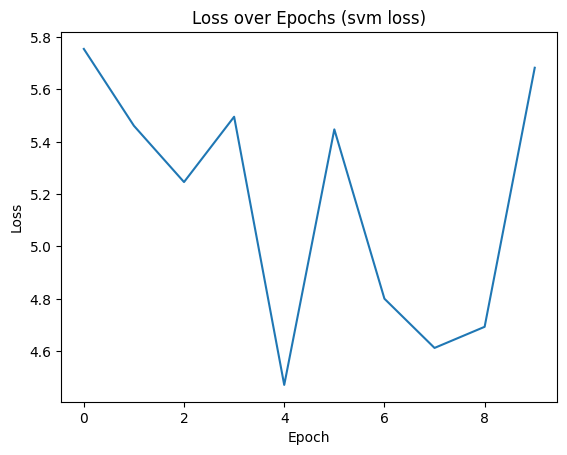

##Задание 9
Поэксперементируйте с параметрами обучения

Epoch 1/10, Loss: 1.8812
Epoch 2/10, Loss: 2.3507
Epoch 3/10, Loss: 1.9103
Epoch 4/10, Loss: 2.0484
Epoch 5/10, Loss: 2.0045
Epoch 6/10, Loss: 2.0570
Epoch 7/10, Loss: 2.1097
Epoch 8/10, Loss: 1.9443
Epoch 9/10, Loss: 1.8626
Epoch 10/10, Loss: 2.1197


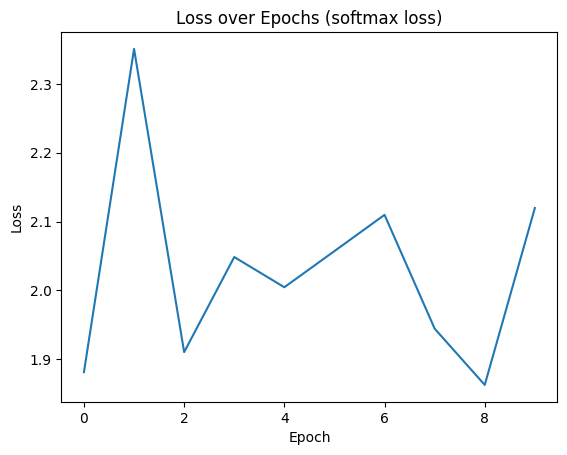

##Задание 10
Выполните оценку качества модели на тестовых данных с помощью classification_report

Epoch 1/20, Loss: 4.7662
Epoch 2/20, Loss: 4.1701
Epoch 3/20, Loss: 5.6959
Epoch 4/20, Loss: 4.3008
Epoch 5/20, Loss: 4.4442
Epoch 6/20, Loss: 4.8222
Epoch 7/20, Loss: 6.4143
Epoch 8/20, Loss: 3.8391
Epoch 9/20, Loss: 3.6256
Epoch 10/20, Loss: 5.8465
Epoch 11/20, Loss: 4.2952
Epoch 12/20, Loss: 3.6606
Epoch 13/20, Loss: 5.8816
Epoch 14/20, Loss: 5.0613
Epoch 15/20, Loss: 6.8237
Epoch 16/20, Loss: 4.0966
Epoch 17/20, Loss: 4.3483
Epoch 18/20, Loss: 6.0168
Epoch 19/20, Loss: 4.4350
Epoch 20/20, Loss: 2.5170


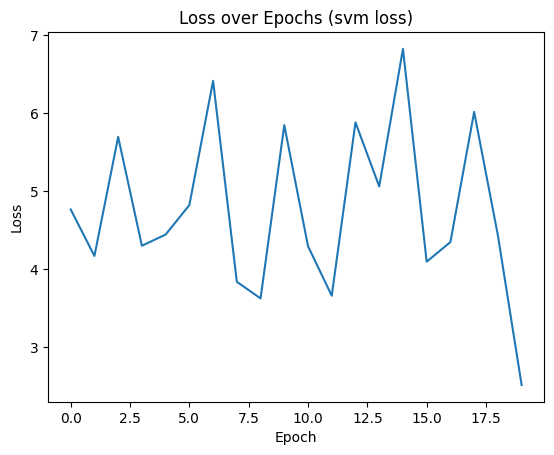

Accuracy: 0.3622
              precision    recall  f1-score   support

           0       0.44      0.23      0.30      1000
           1       0.47      0.37      0.41      1000
           2       0.28      0.20      0.23      1000
           3       0.27      0.26      0.27      1000
           4       0.36      0.33      0.35      1000
           5       0.29      0.39      0.33      1000
           6       0.37      0.47      0.41      1000
           7       0.44      0.35      0.39      1000
           8       0.37      0.53      0.44      1000
           9       0.40      0.49      0.44      1000

    accuracy                           0.36     10000
   macro avg       0.37      0.36      0.36     10000
weighted avg       0.37      0.36      0.36     10000



##Задание 11
Выполните визуализацию изображений, прогнозных значений и реальных значений

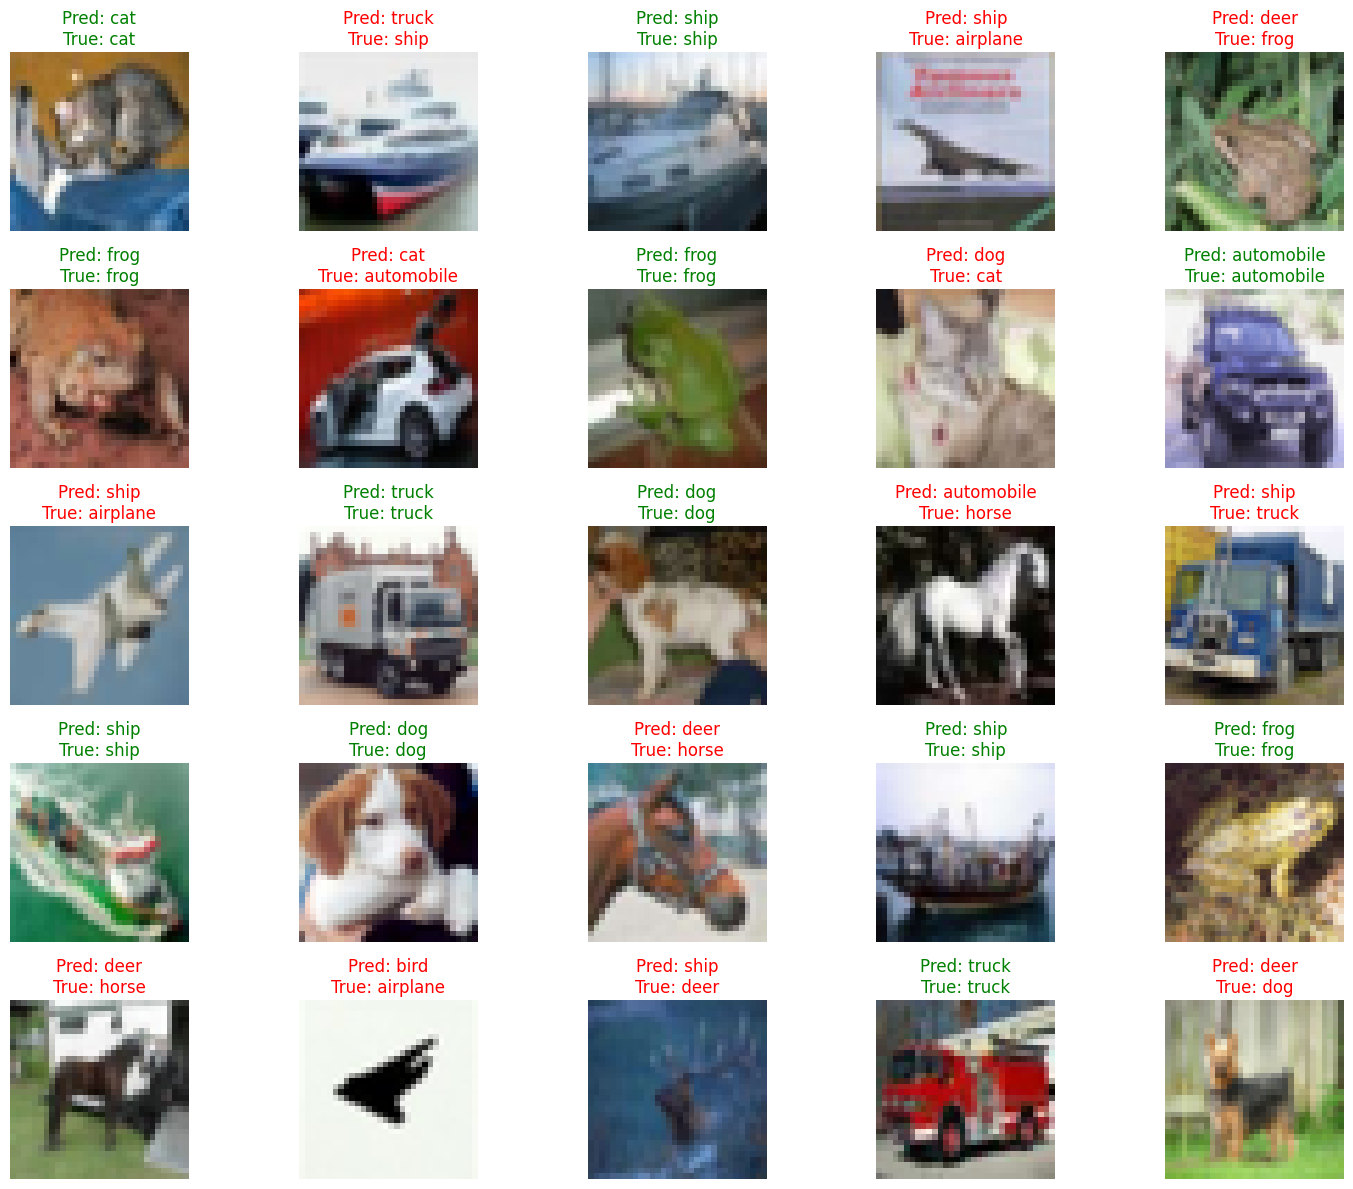

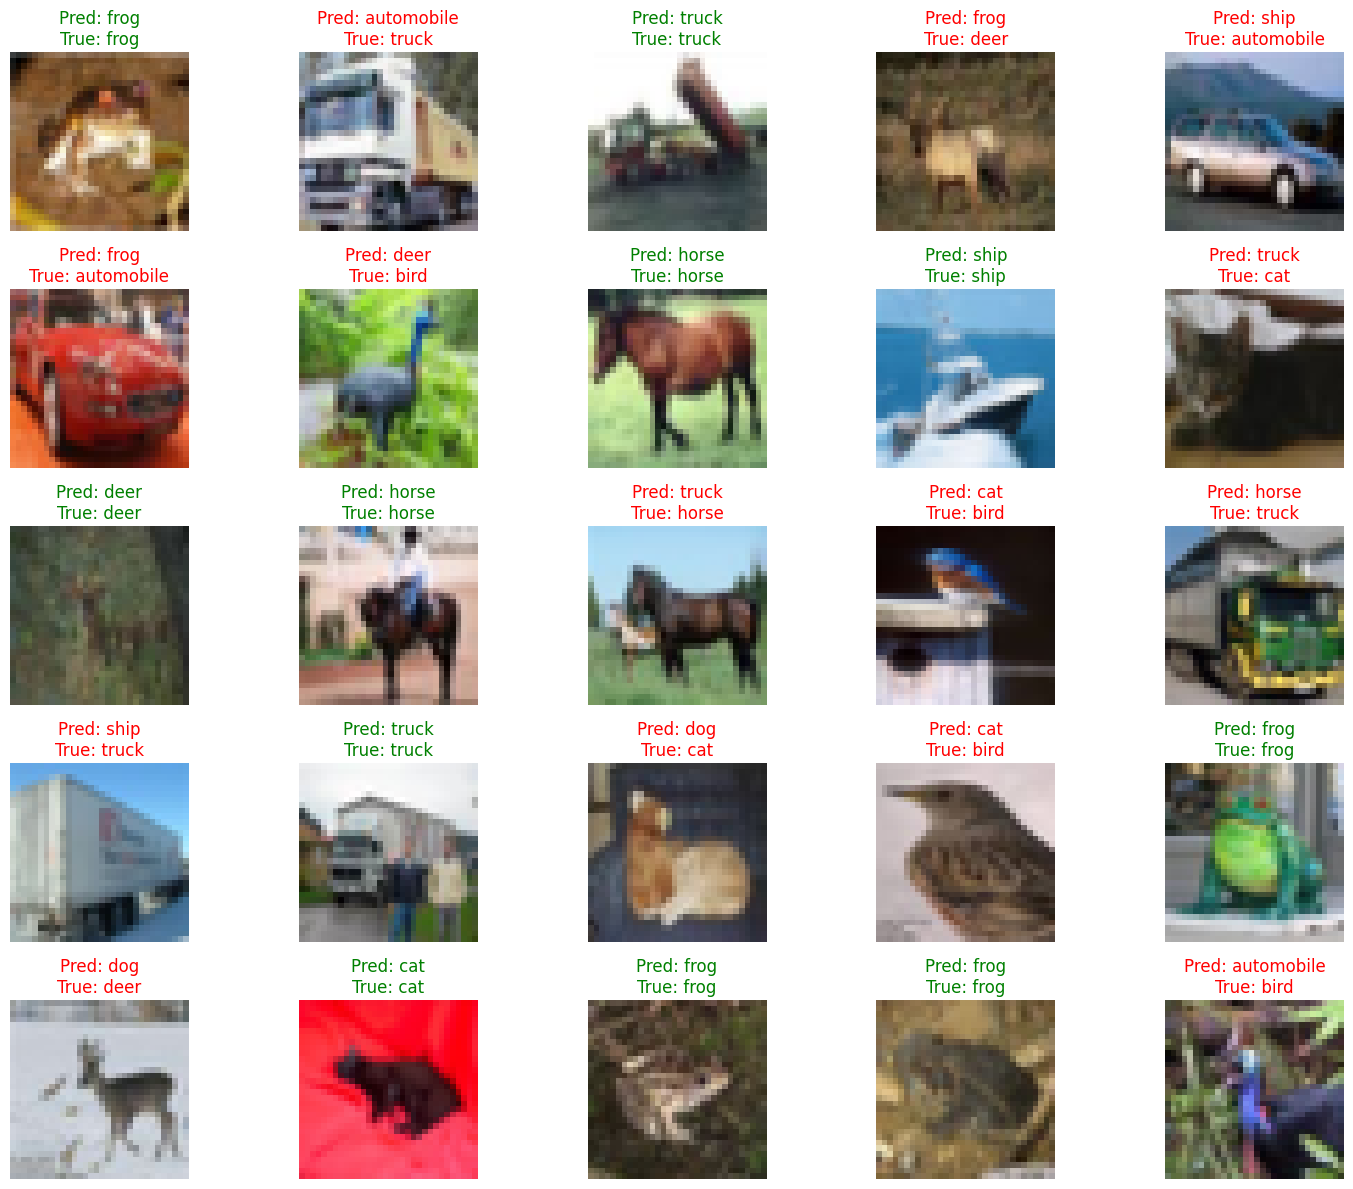

In [ ]:
visualize_predictions(lc, X_train[:100], y_train[:100])

##Задание 14*
Попробуйте сравнить вашу модель со встроенным SVM, Random Forest и LogReg классификаторами

In [ ]:
'''import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


# Модели
models = {
    'SVM': SVC(),
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Random Forest': RandomForestClassifier()
}

# Обучение моделей и оценка производительности
for model_name, model in models.items():
    # Обучаем модель
    model.fit(X_train, y_train)

    # Предсказание на тестовых данных
    y_pred = model.predict(X_test)

    # Оценка и вывод отчета
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=classes#data.target_names)

    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)
    print("-" * 50)
'''

'import numpy as np\nimport pandas as pd\nfrom sklearn.datasets import load_iris\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.svm import SVC\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import classification_report, accuracy_score\n\n\n# Модели\nmodels = {\n    \'SVM\': SVC(),\n    \'Logistic Regression\': LogisticRegression(max_iter=200),\n    \'Random Forest\': RandomForestClassifier()\n}\n\n# Обучение моделей и оценка производительности\nfor model_name, model in models.items():\n    # Обучаем модель\n    model.fit(X_train, y_train)\n    \n    # Предсказание на тестовых данных\n    y_pred = model.predict(X_test)\n    \n    # Оценка и вывод отчета\n    accuracy = accuracy_score(y_test, y_pred)\n    report = classification_report(y_test, y_pred, target_names=classes#data.target_names)\n    \n    print(f"Model: {model_name}")\n    print(f"Accuracy: {accuracy:.4f}")\n    print("Class

In [ ]:

models = {
    'Linear SVM (SGD)': SGDClassifier(
        loss='hinge',
        penalty='l2',
        max_iter=10,
        learning_rate='optimal',
        eta0=0.001,
        random_state=42
    ),
    'Logistic Regression (SGD)': SGDClassifier(
        loss='log_loss',
        penalty='l2',
        max_iter=10,
        learning_rate='optimal',
        eta0=0.001,
        random_state=42
    ),
    'Random Forest (optimized)': RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    )
}

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(



Model: Linear SVM (SGD)
Training time: 28.12 sec
Accuracy: 0.2515
              precision    recall  f1-score   support

    airplane       0.40      0.53      0.45      1000
  automobile       0.61      0.19      0.29      1000
        bird       0.22      0.23      0.22      1000
         cat       0.15      0.41      0.22      1000
        deer       0.44      0.06      0.11      1000
         dog       0.17      0.60      0.27      1000
        frog       0.44      0.17      0.25      1000
       horse       0.64      0.14      0.23      1000
        ship       0.67      0.01      0.02      1000
       truck       0.52      0.17      0.26      1000

    accuracy                           0.25     10000
   macro avg       0.43      0.25      0.23     10000
weighted avg       0.43      0.25      0.23     10000



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(



Model: Logistic Regression (SGD)
Training time: 55.07 sec
Accuracy: 0.2486
              precision    recall  f1-score   support

    airplane       0.43      0.48      0.45      1000
  automobile       0.45      0.37      0.41      1000
        bird       0.23      0.18      0.20      1000
         cat       0.13      0.72      0.22      1000
        deer       0.41      0.06      0.10      1000
         dog       0.38      0.12      0.18      1000
        frog       0.31      0.33      0.32      1000
       horse       0.77      0.08      0.14      1000
        ship       0.59      0.09      0.15      1000
       truck       0.54      0.07      0.12      1000

    accuracy                           0.25     10000
   macro avg       0.42      0.25      0.23     10000
weighted avg       0.42      0.25      0.23     10000


Model: Random Forest (optimized)
Training time: 55.70 sec
Accuracy: 0.4283
              precision    recall  f1-score   support

    airplane       0.52      0.53 

##Задание 15
Создайте нелинейную модель ИНС с одним или более скрытым слоем, обучите ее и проверьте точность. По желанию можно добавить BatchNorm и DropOut слои.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.3071 - loss: 2.0237 - val_accuracy: 0.3789 - val_loss: 1.7721
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4125 - loss: 1.6488 - val_accuracy: 0.3610 - val_loss: 1.7871
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4498 - loss: 1.5524 - val_accuracy: 0.3587 - val_loss: 1.8123
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4593 - loss: 1.5126 - val_accuracy: 0.3585 - val_loss: 1.8010
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4710 - loss: 1.4801 - val_accuracy: 0.3357 - val_loss: 1.8742
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4843 - loss: 1.4480 - val_accuracy: 0.3395 - val_loss: 1.8852
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4818 - loss: 1.4506 - val_accuracy: 0.4193 - val_loss: 1.6337
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4846 - loss: 1.4387 - val_accuracy: 0

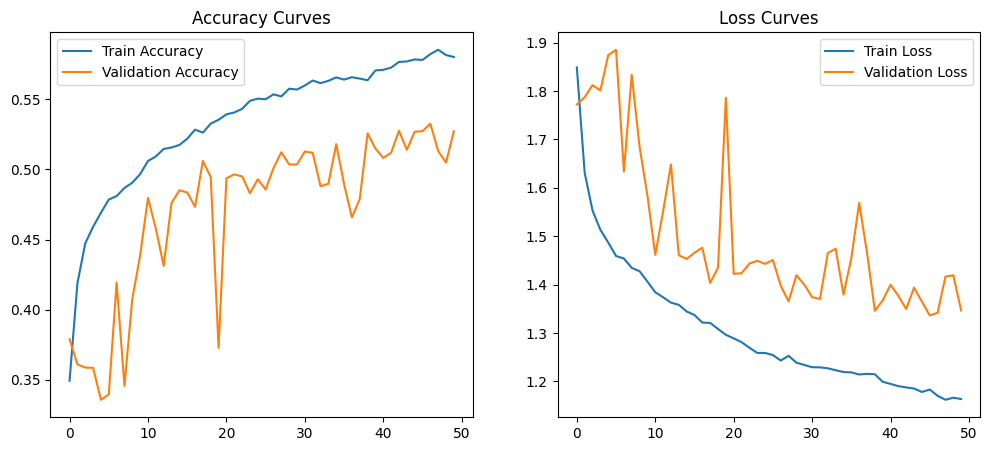

In [ ]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score
